# Sentiment Analysis - ML Training and Testing Notebook
This notebook performs Sentiment Analysis on the **Sentiment140** dataset (`training.1600000.processed.noemoticon.csv`).

## Objectives
1. **Explore and Clean** the dataset of 1.6 million tweets.
2. **Train a Classical ML Model** (TF-IDF + Logistic Regression) as a fast, highly accurate baseline.
3. **Train a PyTorch Deep Learning Model** (BERT Embeddings + `TextModel` from `models.py`) on a subset.
4. **Compare Models** using standard metrics (Accuracy, F1-Score, Confusion Matrix, ROC-AUC).
5. **Save Weights** to `weights/text_model.pt` for integration with the Hybrid Multimodal Fusion network.

## Setup & Imports

In [4]:
import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Append current directory to path to import local modules
sys.path.append(os.path.abspath('.'))
from models import TextModel

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: mps


## 1. Data Loading and Exploration
We load the raw CSV file. The columns are unlabelled, so we assign the official Sentiment140 names.

In [5]:
dataset_path = 'data/training.1600000.processed.noemoticon.csv'

print(f"Loading dataset from {dataset_path}...")
df = pd.read_csv(dataset_path, encoding='latin-1', header=None)
df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

print(f"Total samples: {len(df)}")
df.head()

Loading dataset from data/training.1600000.processed.noemoticon.csv...
Total samples: 1600000


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


### Target Label Mapping
The target values in Sentiment140 are:
- `0`: Negative
- `4`: Positive

We will map `0` -> `0` (Negative) and `4` -> `2` (Positive) to ensure the outputs match the 3-class system used in our Hybrid Multimodal Fusion model (`models.py`), which uses classes: `0` (Negative), `1` (Neutral), and `2` (Positive).

In [6]:
df['label'] = df['target'].map({0: 0, 4: 2})

print("Label distribution:")
print(df['label'].value_counts())

Label distribution:
label
0    800000
2    800000
Name: count, dtype: int64


## 2. Text Preprocessing
We define a robust text cleaning function using regular expressions to remove HTML entities, URL links, user mentions (@usernames), and extra whitespaces.

In [7]:
def clean_text(text):
    text = text.lower()
    # Replace common HTML tags/entities
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'&lt;', '<', text)
    text = re.sub(r'&gt;', '>', text)
    text = re.sub(r'&quot;', '"', text)
    # Remove URL links
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove @mentions
    text = re.sub(r'@\S+', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Let's test the cleaning function
sample_tweet = "@switchfoot http://twitpic.com/2y1zl - Awww, that's &quot;a bummer&quot;."
print("Original:", sample_tweet)
print("Cleaned :", clean_text(sample_tweet))

Original: @switchfoot http://twitpic.com/2y1zl - Awww, that's &quot;a bummer&quot;.
Cleaned : - awww, that's "a bummer".


## 3. Approach 1: Classical Machine Learning Baseline (TF-IDF + Logistic Regression)
To establish a fast baseline, we sample 100,000 tweets, clean them, perform TF-IDF vectorization, and train a Logistic Regression model.

In [8]:
# Sample 100,000 samples for the fast ML baseline
print("Sampling 100,000 tweets...")
df_ml = df.sample(n=100000, random_state=42).copy()

print("Cleaning tweets...")
df_ml['clean_text'] = df_ml['text'].apply(clean_text)
# Remove empty strings
df_ml = df_ml[df_ml['clean_text'] != '']

# Train-test split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    df_ml['clean_text'], df_ml['label'], test_size=0.2, random_state=42, stratify=df_ml['label']
)

# TF-IDF Vectorization
print("Vectorizing text with TF-IDF...")
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train_lr)
X_test_tfidf = vectorizer.transform(X_test_lr)

# Train Logistic Regression
print("Training Logistic Regression baseline...")
lr_model = LogisticRegression(max_iter=1000, C=1.0)
lr_model.fit(X_train_tfidf, y_train_lr)
print("Training complete!")

Sampling 100,000 tweets...
Cleaning tweets...
Vectorizing text with TF-IDF...
Training Logistic Regression baseline...
Training complete!


=== Logistic Regression Baseline Performance ===
              precision    recall  f1-score   support

    Negative       0.80      0.79      0.79      9970
    Positive       0.79      0.80      0.79      9996

    accuracy                           0.79     19966
   macro avg       0.79      0.79      0.79     19966
weighted avg       0.79      0.79      0.79     19966



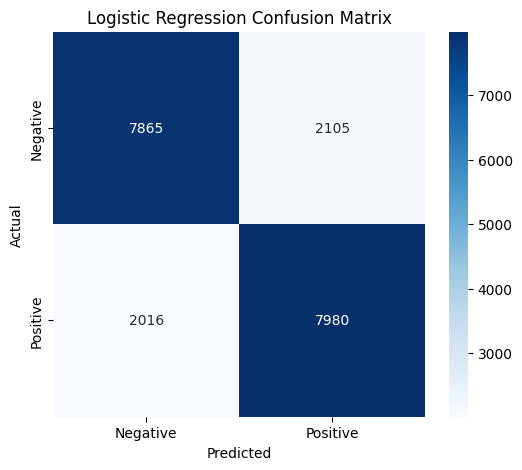

In [9]:
# Predictions and Evaluation
y_pred_lr = lr_model.predict(X_test_tfidf)

print("=== Logistic Regression Baseline Performance ===")
print(classification_report(y_test_lr, y_pred_lr, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm_lr = confusion_matrix(y_test_lr, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 4. Approach 2: Deep Learning Pipeline (BERT Embeddings + PyTorch `TextModel`)
Now, we implement the deep learning training using the `TextModel` defined in the project's `models.py`.
Since extracting BERT embeddings on 1.6M rows takes a long time locally, we extract embeddings from a clean subset of 5,000 samples. We will use Hugging Face's `distilbert-base-uncased` to extract 768-dimensional contextual features.

In [10]:
from transformers import AutoTokenizer, AutoModel

# Sample subset for Deep Learning model
print("Sampling 5,000 tweets for Deep Learning workflow...")
df_dl = df.sample(n=5000, random_state=42).copy()
df_dl['clean_text'] = df_dl['text'].apply(clean_text)
df_dl = df_dl[df_dl['clean_text'] != '']

print("Loading DistilBERT tokenizer and backbone...")
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
bert_backbone = AutoModel.from_pretrained('distilbert-base-uncased').to(device)
bert_backbone.eval()

emb_list = []
texts = df_dl['clean_text'].tolist()
labels = df_dl['label'].tolist()

print("Extracting contextual embeddings (this might take 1-2 minutes)...")
batch_size = 32
with torch.no_grad():
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        tokens = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)
        outputs = bert_backbone(**tokens)
        # Extract mean pooled representation (dim=768)
        embeddings = torch.mean(outputs.last_hidden_state, dim=1).cpu()
        emb_list.append(embeddings)

inputs = torch.cat(emb_list, dim=0)
labels = torch.tensor(labels)
print(f"Embeddings Extraction Complete. Shape: {inputs.shape}")

/Users/sumitkumar776693/Desktop/Project/Client/Sentimental-Analyses-Current/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sampling 5,000 tweets for Deep Learning workflow...
Loading DistilBERT tokenizer and backbone...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6374.71it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting contextual embeddings (this might take 1-2 minutes)...
Embeddings Extraction Complete. Shape: torch.Size([4993, 768])


### PyTorch Dataset and Training
We load the extracted embeddings into a PyTorch DataLoader and train the `TextModel` along with an evaluation classification head.

In [ ]:
# Create datasets & loader
dl_dataset = TensorDataset(inputs, labels)
train_size = int(0.8 * len(dl_dataset))
val_size = len(dl_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dl_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Initialize TextModel from models.py
model = TextModel(pretrained_dim=768, feature_dim=256).to(device)
eval_classifier = nn.Linear(256, 3).to(device) # maps to 3 classes (0: Neg, 1: Neu, 2: Pos)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(list(model.parameters()) + list(eval_classifier.parameters()), lr=0.001)

# Training Loop
epochs = 12
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("=== Training deep learning model ===")
for epoch in range(epochs):
    model.train()
    eval_classifier.train()
    train_loss, correct, total = 0.0, 0, 0
    
    for batch_inputs, batch_labels in train_loader:
        batch_inputs, batch_labels = batch_inputs.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        features = model(batch_inputs)
        logits = eval_classifier(features)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_inputs.size(0)
        _, predicted = logits.max(1)
        total += batch_labels.size(0)
        correct += predicted.eq(batch_labels).sum().item()
        
    epoch_loss = train_loss / total
    epoch_acc = correct / total
    
    # Validation
    model.eval()
    eval_classifier.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch_inputs, batch_labels in val_loader:
            batch_inputs, batch_labels = batch_inputs.to(device), batch_labels.to(device)
            features = model(batch_inputs)
            logits = eval_classifier(features)
            loss = criterion(logits, batch_labels)
            
            val_loss += loss.item() * batch_inputs.size(0)
            _, predicted = logits.max(1)
            val_total += batch_labels.size(0)
            val_correct += predicted.eq(batch_labels).sum().item()
            
    val_epoch_loss = val_loss / val_total
    val_epoch_acc = val_correct / val_total
    
    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(val_epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_acc'].append(val_epoch_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

=== Training deep learning model ===
Epoch 1/8 - Loss: 0.5858, Acc: 0.7126 | Val Loss: 0.5130, Val Acc: 0.7578
Epoch 2/8 - Loss: 0.4657, Acc: 0.7792 | Val Loss: 0.5125, Val Acc: 0.7588
Epoch 3/8 - Loss: 0.4260, Acc: 0.8035 | Val Loss: 0.5589, Val Acc: 0.7427
Epoch 4/8 - Loss: 0.3976, Acc: 0.8222 | Val Loss: 0.5497, Val Acc: 0.7427
Epoch 5/8 - Loss: 0.3712, Acc: 0.8315 | Val Loss: 0.6518, Val Acc: 0.7337
Epoch 6/8 - Loss: 0.3301, Acc: 0.8548 | Val Loss: 0.5847, Val Acc: 0.7538
Epoch 7/8 - Loss: 0.3079, Acc: 0.8683 | Val Loss: 0.5893, Val Acc: 0.7467
Epoch 8/8 - Loss: 0.2890, Acc: 0.8768 | Val Loss: 0.6267, Val Acc: 0.7417


### Training Metrics & Deep Learning Model Evaluation
We plot the training curves and evaluate the trained model on our validation set.

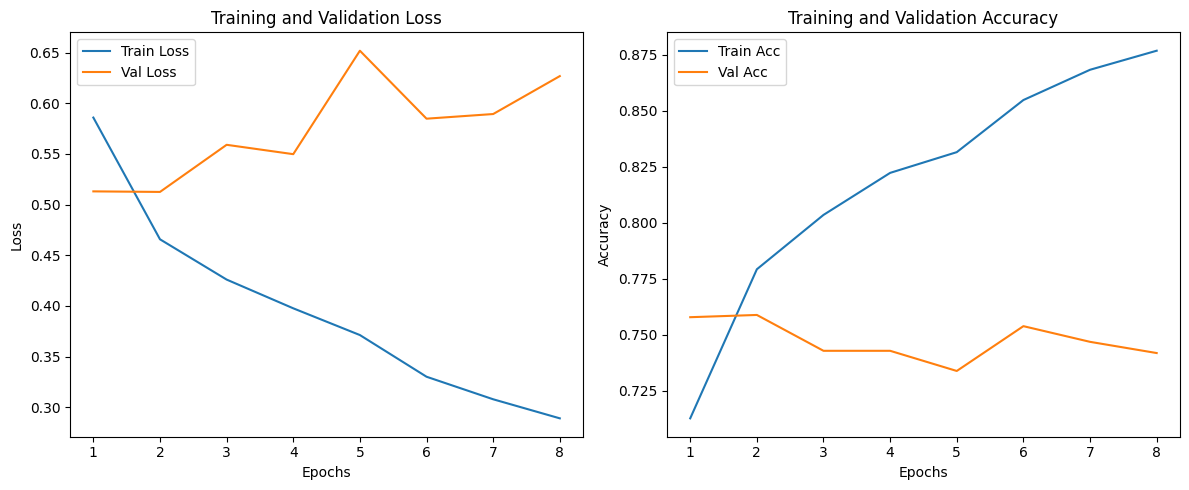

=== PyTorch TextModel + DistilBERT Performance ===
              precision    recall  f1-score   support

    Negative       0.80      0.64      0.71       495
    Positive       0.70      0.84      0.77       504

    accuracy                           0.74       999
   macro avg       0.75      0.74      0.74       999
weighted avg       0.75      0.74      0.74       999



In [12]:
# Plot training history
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc')
plt.plot(epochs_range, history['val_acc'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Classification Report on Validation Set
model.eval()
eval_classifier.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_inputs, batch_labels in val_loader:
        batch_inputs = batch_inputs.to(device)
        features = model(batch_inputs)
        logits = eval_classifier(features)
        _, predicted = logits.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(batch_labels.numpy())

print("=== PyTorch TextModel + DistilBERT Performance ===")
print(classification_report(all_targets, all_preds, labels=[0, 2], target_names=['Negative', 'Positive']))

## 5. Model Comparison and Saving Weights
We compare the performance metrics, plot the ROC curve for both models, and save the trained PyTorch `TextModel` weights to `weights/text_model.pt` so that it can be loaded by other project scripts like `train_fusion.py`.

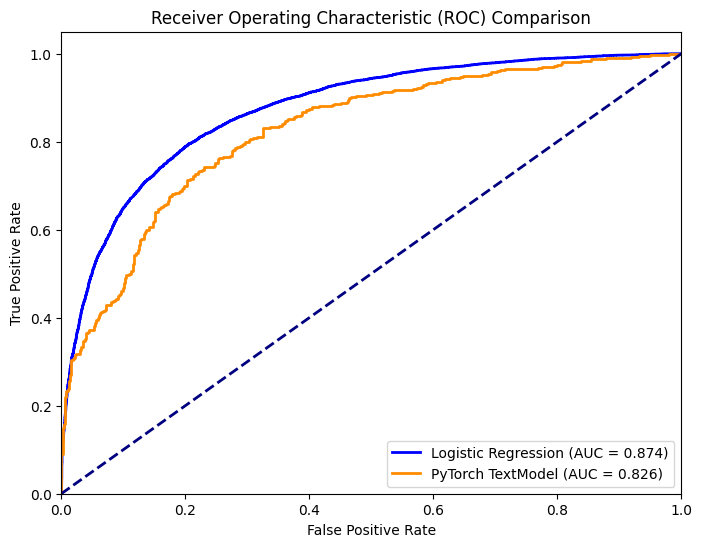

Successfully saved text model weights to ../weights/text_model.pt


In [13]:
# 1. ROC Curve comparison
plt.figure(figsize=(8, 6))

# Logistic Regression ROC
y_score_lr = lr_model.predict_proba(X_test_tfidf)[:, 1] # probability of positive class (label 2)
# Map test targets to binary for ROC (0 and 2 mapped to 0 and 1)
y_test_binary = (y_test_lr == 2).astype(int)
fpr_lr, tpr_lr, _ = roc_curve(y_test_binary, y_score_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')

# Deep Learning ROC
dl_probs = []
dl_targets_binary = []
with torch.no_grad():
    for batch_inputs, batch_labels in val_loader:
        batch_inputs = batch_inputs.to(device)
        features = model(batch_inputs)
        logits = eval_classifier(features)
        probs = torch.softmax(logits, dim=-1)
        dl_probs.extend(probs[:, 2].cpu().numpy()) # class 2 is positive
        dl_targets_binary.extend((batch_labels == 2).numpy().astype(int))

fpr_dl, tpr_dl, _ = roc_curve(dl_targets_binary, dl_probs)
roc_auc_dl = auc(fpr_dl, tpr_dl)
plt.plot(fpr_dl, tpr_dl, color='darkorange', lw=2, label=f'PyTorch TextModel (AUC = {roc_auc_dl:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.show()

# 2. Save PyTorch Model weights
os.makedirs('../weights', exist_ok=True)
weight_path = '../weights/text_model.pt'
torch.save(model.state_dict(), weight_path)
print(f"Successfully saved text model weights to {weight_path}")